# Imports

In [1]:
# Linear algebra
import numpy as np

# Dataframes
import pandas as pd

# Path
import os
data_path = os.path.join('..', 'data')

# Load Data

In [2]:
c = 0.5

# Load datasets
train_df = pd.read_pickle(os.path.join(data_path, f"0_train_{int(100 * c)}.pkl"))
validation_df = pd.read_pickle(os.path.join(data_path, f"1_validation_{int(100 * c)}.pkl"))
test_df = pd.read_pickle(os.path.join(data_path, f"2_test_{int(100 * c)}.pkl"))

# Merge datasets
all_df = pd.concat([train_df, validation_df, test_df], ignore_index=True)

In [6]:
all_df

,cluster,length (aa),gene,transcript,seq,amino_acid_seq,median
0,14391,70,ENSG00000172809,ENST00000311111,ATGCCTCGGAAAATTGAGGAAATCAAGGACTTCCTGCTCACAGCCC...,MPRKIEEIKDFLLTARRKDAKSVKIKKNKDNVKFKVRCSRYLYTLV...,"(expr_top10, expr_top10, expr_top10, expr_top1..."
1,9132,279,ENSG00000163956,ENST00000648517,ATGGCGCCGCGGAGGGTCAGGTCGTTTCTGCGCGGGCTCCCGGCGC...,MAPRRVRSFLRGLPALLLLLLFLGPWPAASHGGKYSREKNQPKPSP...,NaN
2,11849,232,ENSG00000101695,ENST00000217740,ATGGGCTCCGTGCTGAGCACCGACAGCGGCAAATCGGCGCCCGCCT...,MGSVLSTDSGKSAPASATARALERRRDPELPVTSFDCAVCLEVLHQ...,"(expr_pre75_90, expr_pre75_90, expr_pre50_75, ..."
3,2854,849,ENSG00000168907,ENST00000397272,ATGCTTTGGGCACTCTGGCCAAGGTGGCTGGCAGACAAGATGCTGC...,MLWALWPRWLADKMLPLLGAVLLQKREKRGPLWRHWRRETYPYYDL...,"(expr_pre25_50, expr_pre25_50, expr_low25, exp..."
4,8137,406,ENSG00000188488,ENST00000554276,ATGCAGCTCTTCCTCCTCTTGTGCCTGGTGCTTCTCAGCCCTCAGG...,MQLFLLLCLVLLSPQGASLHRHHPREMKKRVEDLHVGATVAPSSRR...,"(expr_pre25_50, expr_pre25_50, expr_top10, exp..."
...,...,...,...,...,...,...,...
80088,3560,726,ENSG00000081277,ENST00000367324,ATGAACCACTCGCCGCTCAAGACCGCCTTGGCGTACGAATGCTTCC...,MNHSPLKTALAYECFQDQDNSTLALPSDQKMKTGTSGRQRVQEQVM...,"(expr_pre75_90, expr_pre75_90, expr_pre25_50, ..."
80089,3464,758,ENSG00000105298,ENST00000429344,ATGGGTCGGGACACACGCTCGCGCTCGCGGTCCGCGGGTCGCCGGG...,MGRDTRSRSRSAGRRGRRRQSQSGSRSRSRSHGRRNRRRREDEGRR...,"(expr_pre75_90, expr_pre75_90, expr_pre75_90, ..."
80090,2613,153,ENSG00000066468,ENST00000683035,ATGGTCAGCTGGGGTCGTTTCATCTGCCTGGTCGTGGTCACCATGG...,MVSWGRFICLVVVTMATLSLARPSFSLVEDTTLEPEEPPTKYQISQ...,NaN
80091,530,61,ENSG00000197892,ENST00000522355,ATGGGGGACTCCAAAGTGAAAGTGGCGGTGCGGATACGACCCATGA...,MGDSKVKVAVRIRPMNRRETDLHTKCVVDVDANKVILNPVNTNLSK...,"(expr_low25, expr_low25, expr_pre25_50, expr_l..."


In [7]:
# Read representatives file
cluster_path = os.path.join(data_path, f"proteins_human_{int(100 * c)}.fasta")
column_names = [0, 1, 2]
cluster_df = pd.read_csv(cluster_path, delimiter=r'\t| |,|>|\|', header=None, engine='python', names=column_names)

In [8]:
cluster_df

,0,1,2
0,NaN,ENSG00000000005,ENST00000373031
1,MAKNPPENCEDCHILNAEAFKSKKICKSLKICGLVFGILALTLIVL...,None,None
2,NaN,ENSG00000000419,ENST00000371584
3,MASLEVSRSPRRSRRELEVRSPRQNKYSVLLPTYNERENLPLIVWL...,None,None
4,NaN,ENSG00000000457,ENST00000367770
...,...,...,...
34499,MFLQKELVCSPLIADQLPWVLLMTQESFA*,None,None
34500,NaN,ENSG00000291315,ENST00000706951
34501,MIPCSKRTFHLFNHSNFHSHLHDYRKHGVCRLVTHKKIAVRW*,None,None
34502,NaN,ENSG00000291317,ENST00000403000


# Clean representatives dataframe

In [9]:
# Fill in protein sequences for each row
cluster_df[0] = cluster_df[0].bfill()

# Drop NaN-containing rows
cluster_df.dropna(inplace=True)

# Rename and reorder columns
cluster_df = cluster_df[[1, 2, 0]]
cluster_df.columns = ['gene', 'transcript', 'amino_acid_seq']
cluster_df

,gene,transcript,amino_acid_seq
0,ENSG00000000005,ENST00000373031,MAKNPPENCEDCHILNAEAFKSKKICKSLKICGLVFGILALTLIVL...
2,ENSG00000000419,ENST00000371584,MASLEVSRSPRRSRRELEVRSPRQNKYSVLLPTYNERENLPLIVWL...
4,ENSG00000000457,ENST00000367770,MGSENSALKSYTLREPPFTLPSGLAVYPAVLQDGKFASVFVYKREN...
6,ENSG00000000460,ENST00000359326,MFLPHMNHLTLEQTFFSQVLPKTVKLFDDMMYELTSQARGLSSQNL...
8,ENSG00000000460,ENST00000481744,MSQEGAVPASAVPLEELSSWPEELCRRELPSVLPRLLSLSQHSDSW...
...,...,...,...
34494,ENSG00000291309,ENST00000706920,MSSLQAMKTLSLVLLVALLSMERAQGLRCYRCLAVLEGASCSVVSC...
34496,ENSG00000291313,ENST00000706947,MSLFDENELLRSHWYLYWGNIAYKQEAYSLSGENFFMSETENSCSR...
34498,ENSG00000291314,ENST00000706950,MFLQKELVCSPLIADQLPWVLLMTQESFA*
34500,ENSG00000291315,ENST00000706951,MIPCSKRTFHLFNHSNFHSHLHDYRKHGVCRLVTHKKIAVRW*


In [10]:
# Merge cluster representatives with updated-cluster numbers (after uniting clusters with same gene)
merged_df = pd.merge(cluster_df, all_df, on='transcript', how='left')

# Drop duplicate columns
merged_df.drop(columns=['gene_y', 'amino_acid_seq_y'], inplace=True)

# Rename columns
merged_df.rename(columns={'gene_x': 'gene', 'amino_acid_seq_x': 'amino_acid_seq'}, inplace=True)

# Drop duplicate-cluster representatives (keep first)
merged_df = merged_df.loc[~merged_df.duplicated(subset='cluster', keep='first')]

# Reset index
merged_df.reset_index(drop=True, inplace=True)

In [11]:
merged_df

,gene,transcript,amino_acid_seq,cluster,length (aa),seq,median
0,ENSG00000000005,ENST00000373031,MAKNPPENCEDCHILNAEAFKSKKICKSLKICGLVFGILALTLIVL...,10068,317,ATGGCAAAGAATCCTCCAGAGAATTGTGAAGACTGTCACATTCTAA...,"(expr_top10, expr_pre75_90, expr_low25, expr_p..."
1,ENSG00000000419,ENST00000371584,MASLEVSRSPRRSRRELEVRSPRQNKYSVLLPTYNERENLPLIVWL...,10563,295,ATGGCCTCCTTGGAAGTCAGTCGTAGTCCTCGCAGGTCTCGGCGGG...,"(expr_pre50_75, expr_pre50_75, expr_pre50_75, ..."
2,ENSG00000000457,ENST00000367770,MGSENSALKSYTLREPPFTLPSGLAVYPAVLQDGKFASVFVYKREN...,3604,742,ATGGGATCAGAGAACAGTGCTTTAAAGAGCTATACACTGAGAGAAC...,"(expr_pre50_75, expr_pre50_75, expr_pre50_75, ..."
3,ENSG00000000460,ENST00000359326,MFLPHMNHLTLEQTFFSQVLPKTVKLFDDMMYELTSQARGLSSQNL...,2831,853,ATGTTTTTACCTCATATGAACCACCTGACATTGGAACAGACTTTCT...,"(expr_pre25_50, expr_pre50_75, expr_pre50_75, ..."
4,ENSG00000001036,ENST00000002165,MRPQELPRLAFPLLLLLLLLLPPPPCPAHSATRFDPTWESLDARQL...,7014,467,ATGCGGCCCCAGGAGCTCCCCAGGCTCGCGTTCCCGTTGCTGCTGT...,"(expr_top10, expr_top10, expr_top10, expr_top1..."
...,...,...,...,...,...,...,...
14416,ENSG00000291309,ENST00000706920,MSSLQAMKTLSLVLLVALLSMERAQGLRCYRCLAVLEGASCSVVSC...,13694,134,ATGAGCAGTCTCCAGGCCATGAAGACCTTGTCCCTGGTCCTGCTGG...,NaN
14417,ENSG00000291313,ENST00000706947,MSLFDENELLRSHWYLYWGNIAYKQEAYSLSGENFFMSETENSCSR...,14184,97,ATGTCTTTATTTGACGAAAACGAGCTGTTGCGCAGCCATTGGTACC...,NaN
14418,ENSG00000291314,ENST00000706950,MFLQKELVCSPLIADQLPWVLLMTQESFA*,14501,29,ATGTTTCTTCAAAAAGAACTAGTGTGCAGTCCATTGATAGCTGATC...,NaN
14419,ENSG00000291315,ENST00000706951,MIPCSKRTFHLFNHSNFHSHLHDYRKHGVCRLVTHKKIAVRW*,14485,42,ATGATTCCCTGCAGTAAACGGACTTTTCATTTATTTAATCATTCAA...,NaN


# Save Representatives

## As Pickle

In [12]:
# Save to pickle
merged_df.to_pickle(os.path.join(data_path, f"proteins_human_{int(100 * c)}_representatives.pkl"))

## As Fasta

In [13]:
# Load the merged dataframe from pickle file
merged_df = pd.read_pickle(os.path.join(data_path, f"proteins_human_{int(100 * c)}_representatives.pkl"))

# Save as fasta to data path
with open(os.path.join(data_path, f"proteins_human_{int(100 * c)}_representatives.fasta"), 'w') as fasta_file:
    for index, row in merged_df.iterrows():
        fasta_file.write(f">{row['gene']}|{row['transcript']}\n{row['amino_acid_seq']}\n")

### Save representative fasta with only trainset sequences

In [31]:
filtered_merged_df = merged_df[merged_df['transcript'].isin(train_df['transcript'])]

# Save as fasta to data path
with open(os.path.join(data_path, f"proteins_human_{int(100 * c)}_trainset_representatives.fasta"), 'w') as fasta_file:
    for index, row in filtered_merged_df.iterrows():
        fasta_file.write(f">{row['gene']}|{row['transcript']}\n{row['amino_acid_seq']}\n")

### Save fasta with testset sequences

In [4]:
# Save as fasta to data path
with open(os.path.join(data_path, f"proteins_human_{int(100 * c)}_testset.fasta"), 'w') as fasta_file:
    for index, row in test_df.iterrows():
        fasta_file.write(f">{row['gene']}|{row['transcript']}\n{row['amino_acid_seq']}\n")

# Graph Pie Chart

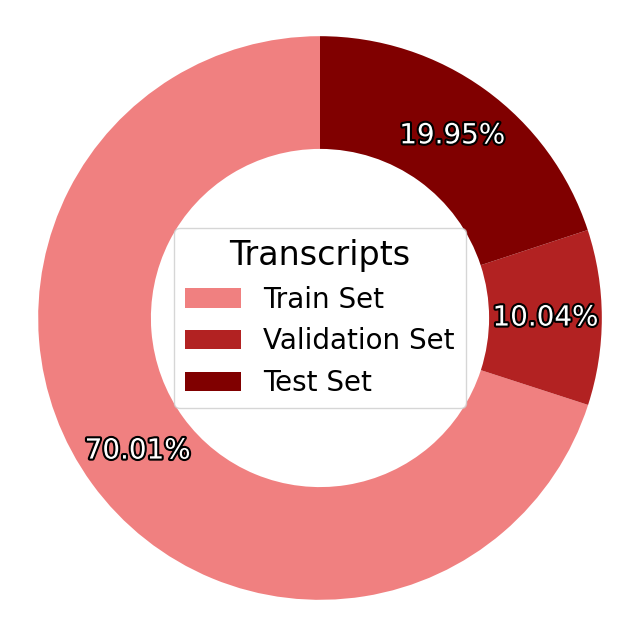

In [43]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

# Number of samples in each dataset
num_train = len(train_df)
num_validation = len(validation_df)
num_test = len(test_df)

# Pie chart
labels = ['Train Set', 'Validation Set', 'Test Set']
sizes = [num_train, num_validation, num_test]
colors = ['lightcoral', 'firebrick', 'maroon']
# red tones: ['lightcoral', 'indianred', 'firebrick']

plt.figure(figsize=(8, 8))

# Adjust the startangle to change the orientation
wedges, texts, autotexts = plt.pie(sizes, colors=colors, autopct='%1.2f%%', startangle=90, textprops=dict(color="black"), wedgeprops=dict(width=0.4), pctdistance=0.8)
for autotext in autotexts:
    autotext.set_fontsize(20)
    autotext.set_color('white')
    # black border to text
    autotext.set_path_effects([pe.withStroke(linewidth=3, foreground='black')])

plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

# Add a legend below the pie chart
plt.legend(wedges, labels, title="Transcripts", loc="center", fontsize=20, title_fontsize=24)

# Save the figure as an SVG file
plt.savefig('datasets_pie_chart.svg', format='svg', transparent=True, bbox_inches='tight')

plt.show()